# CAMS Air Pollution - flash-aurora Engine

Same setup as the upstream [Microsoft Aurora CAMS example](microsoft-aurora/docs/example_cams.ipynb):

- **Date:** 2022-06-11 (analysis at UTC 12:00 from 00:00 + 12:00 inputs)
- **Rollout:** 4 steps → 12 Jun 00/12 and 13 Jun 00/12 UTC
- **Model:** `AuroraAirPollution` via preset `cams`

`CamsAdapter` reads cached NetCDF under `<ASSET_ROOT>/cams/` and loads pollution static fields from `aurora-0.4-air-pollution-static.pickle` in `ASSET_ROOT`.

> **ADS endpoint:** CAMS uses the [Atmosphere Data Store](https://ads.atmosphere.copernicus.eu/). `DataDownloader` always talks to the ADS API URL for you—the same Copernicus UID key as CDS works; you do **not** need to edit `url` in `~/.cdsapirc`.

> **Asset root:** default is `./assets` under the working directory. Here we use the data disk in developing environment, comment `ASSET_ROOT = Path("/root/autodl-tmp/aurora")` in the setup cell to use your own disk.

## Prerequisites

1. **ADS account** and accepted dataset terms for [CAMS global composition forecasts](https://ads.atmosphere.copernicus.eu/datasets/cams-global-atmospheric-composition-forecasts).
2. **ADS credentials** (any one): `ADSAPI_KEY`, `CDSAPI_KEY` (same UID key), `~/.cdsapirc` (`key:` line only), or interactive `getpass` below.
3. **Checkpoint** and **`aurora-0.4-air-pollution-static.pickle`** under `ASSET_ROOT`, or Hugging Face download in the setup cell (independent of ADS ingress in section 1).


## Set up data downloader and engine

In [2]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "cams"
VALID_TIME = datetime(2022, 6, 11, 12)
TIME_INDEX = 1
ROLLOUT_STEPS = 4

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision=INFERENCE_PRECISION,
)

print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))

from flash_aurora.engine.core.hub import HubDownloadOptions
from flash_aurora.engine.core.paths import AssetStore

static_pickle = ASSET_ROOT / variant.static_pickle
hf_options = HubDownloadOptions(endpoint=hf_endpoint)
if static_pickle.is_file():
    print("static_pickle:", safe_path(static_pickle))
else:
    print("static_pickle not found locally; will download from Hugging Face")
    static_pickle = AssetStore(root=ASSET_ROOT).fetch_hub_file(
        variant.static_pickle,
        repo=variant.hf_repo,
        allow_download=True,
        explicit=ASSET_ROOT,
        hub=hf_options,
    )
    print("static_pickle ready:", safe_path(static_pickle))



checkpoint: ~/autodl-tmp/aurora/aurora-0.4-air-pollution.ckpt
cache_dir: ~/autodl-tmp/aurora/cams
asset_root: ~/autodl-tmp/aurora
static_pickle: ~/autodl-tmp/aurora/aurora-0.4-air-pollution-static.pickle


## 1. Download CAMS (ADS API)

`DataDownloader.ensure()` retrieves the upstream CAMS zip from ADS, unpacks surface and atmospheric NetCDF files under `<ASSET_ROOT>/cams/`, and skips the API call when the cache is already complete.


In [3]:
import getpass
import os

from flash_aurora.engine.ingress.download.paths import read_cdsapirc_key

missing_files = downloader.missing(VALID_TIME)
ads_api_key = None

if missing_files:
    ads_api_key = (
        os.environ.get("ADSAPI_KEY", "").strip()
        or os.environ.get("CDSAPI_KEY", "").strip()
        or read_cdsapirc_key()
        or None
    )
    if ads_api_key is None:
        ads_api_key = getpass.getpass("ADS API key (Copernicus UID): ").strip() or None
    if not ads_api_key:
        raise ValueError(
            "No ADS credentials found. Set ADSAPI_KEY, CDSAPI_KEY, "
            "add key: to ~/.cdsapirc, or paste your key when prompted."
        )
    print("Downloading missing CAMS files:", missing_files)

result = downloader.ensure(VALID_TIME, ads_api_key=ads_api_key)
print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


downloaded: ()
skipped: ('surface', 'atmospheric')
  surface: ~/autodl-tmp/aurora/cams/2022-06-11-cams-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/cams/2022-06-11-cams-atmospheric.nc


## 2–3. Build Initial Condition, load model, rollout

`CamsAdapter` selects `forecast_period=0` (analysis) and uses the latest `valid_time` (UTC 12) as IC metadata — same semantics as upstream.


In [5]:
import torch

from flash_aurora.aurora.model.inference_precision import describe_inference_config

request = downloader.ingest_request(VALID_TIME, time_index=TIME_INDEX, download=False)
batch = InitialConditionBuilder(engine.config).from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)

engine.load(rollout_steps=ROLLOUT_STEPS)
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

with torch.inference_mode():
    preds = [pred.to("cpu") for pred in engine.rollout_stream(batch, ROLLOUT_STEPS)]

print("predictions:", [str(p.metadata.time[0]) for p in preds])


IC time: (datetime.datetime(2022, 6, 11, 12, 0),)
spatial: torch.Size([451, 900])
device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
predictions: ['2022-06-12 00:00:00', '2022-06-12 12:00:00', '2022-06-13 00:00:00', '2022-06-13 12:00:00']


## 4. Visualize pollution fields

Same layout as the upstream example: 2×2 panels of **Aurora predictions** for each rollout step (12 Jun 00/12 and 13 Jun 00/12 UTC). Units scaled like upstream; no ground-truth comparison.


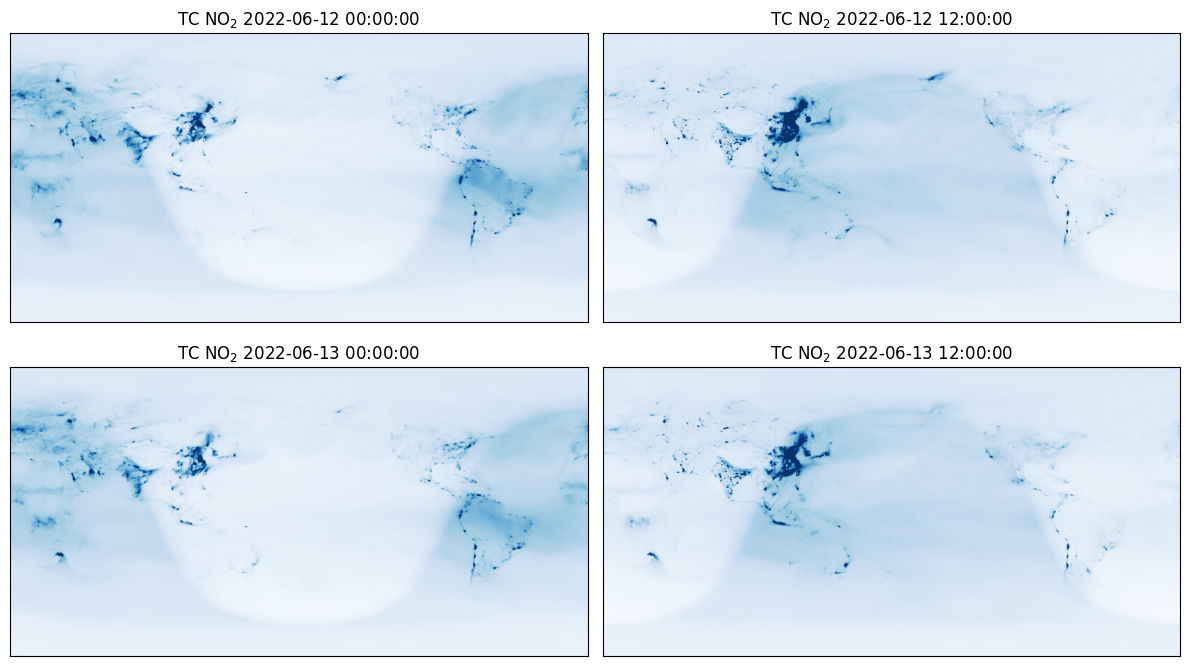

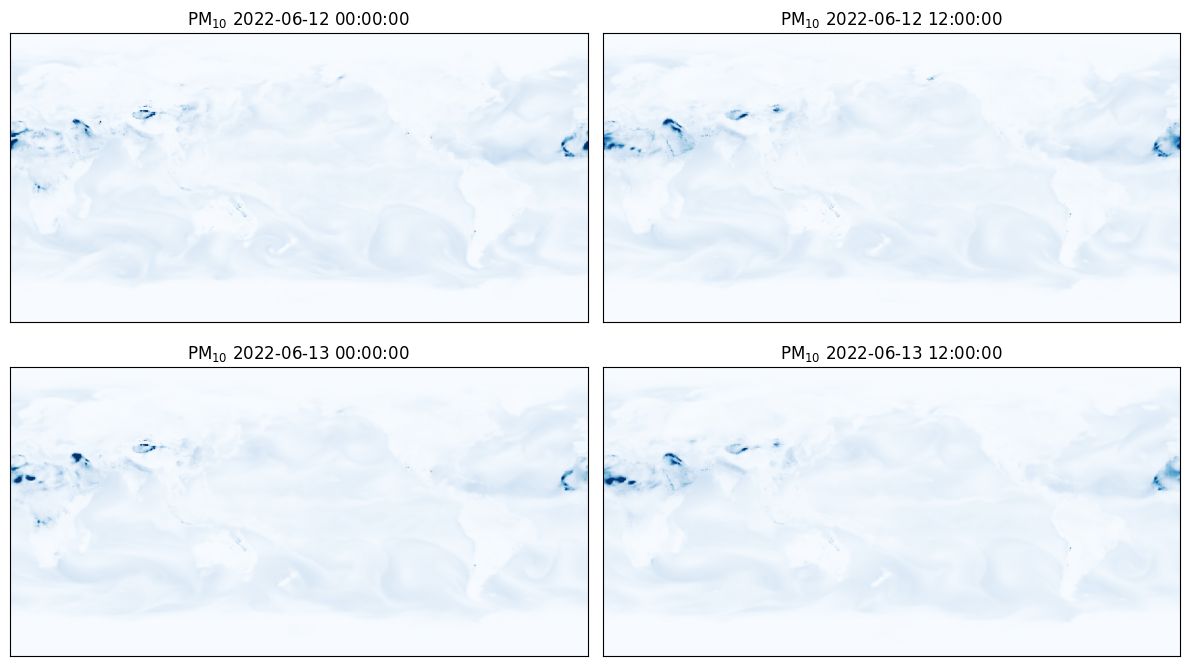

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for i in range(4):
    ax = axs[i // 2, i % 2]
    pred = preds[i]
    ax.imshow(pred.surf_vars["tcno2"][0, 0].numpy() / 1e-6, vmin=0, vmax=10, cmap="Blues")
    ax.set_title(f"TC NO$_2$ {pred.metadata.time[0]}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for i in range(4):
    ax = axs[i // 2, i % 2]
    pred = preds[i]
    ax.imshow(pred.surf_vars["pm10"][0, 0].numpy() / 1e-9, vmin=0, vmax=400, cmap="Blues")
    ax.set_title(f"PM$_{{10}}$ {pred.metadata.time[0]}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


## 5. (Optional) Export rollout to NetCDF


In [ ]:
EXPORT_DIR = ASSET_ROOT / "output" / PRESET
export_paths = list(engine.rollout_and_export(batch, ROLLOUT_STEPS, export_dir=EXPORT_DIR))
for path in export_paths:
    print(safe_path(path))

In [ ]:
engine.release_gpu()
del engine